In [1]:
# =============================================================================
# End-to-end pipeline runner
# =============================================================================
# Executes all four phases in sequence and saves outputs to outputs/.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings('ignore')

from src.config import (
    OHLCV_PATH, N_TRAIN_DAYS, LOT_SIZE, FEE_PER_SHARE, MAX_INV_SHARES,
    GAMMA_GRID_LOG_LO, GAMMA_GRID_LOG_HI, GAMMA_GRID_POINTS,
    Q_MAX_TRIGGER, T_CLOSE, GAMMA_STAR_DEFAULT,
)
from src.data_loader import (
    load_all_sheets, build_calibration_date_split,
    build_price_matrices, preprocess_train_data
)
from src.calibration import calibrate_all_assets, calibrate_eta
from src.risk_matrix import build_sigma, build_Gamma, build_covariance
from src.as_bergault import gamma_sharpe_sweep
from src.almgren_chriss import solve_almgren_chriss, compute_twap_cost
from src.simulation import simulate_integrated, compute_stats, simulate_ablation

os.makedirs("outputs", exist_ok=True)

In [2]:
raw_sheets  = load_all_sheets(OHLCV_PATH)
asset_names = list(raw_sheets.keys())
asset_data  = {name: preprocess_train_data(raw_sheets[name]) for name in asset_names}


In [3]:
train_date_set, test_date_set = build_calibration_date_split(asset_data, N_TRAIN_DAYS)

prices_all, highs_all, lows_all, timestamps, \
    train_day_indices, test_day_indices = build_price_matrices(
        asset_data, asset_names, train_date_set, test_date_set)

Avec, kvec = calibrate_all_assets(asset_data, asset_names, train_date_set)
phase1_df = pd.DataFrame({'ticker': asset_names, 'A': Avec, 'k': kvec})
phase1_df.to_csv("outputs/phase1_A_k.csv", index=False)    


   Asset          A          k
--------------------------------
    AAPL     1.5621    13.8023
    NVDA     1.7848    12.5443
    AMZN     1.6017    13.7534
    MSFT     1.5742     7.9823
    AVGO     1.6560     5.2460
    META     1.7348     4.4836
    TSLA     1.9870     4.3439
   BRK-B     1.6500    10.3826
     WMT     1.5726    37.2008
     LLY     1.5156     2.6004
     JPM     1.6269    11.3410
     XOM     1.6492    37.6220
       V     1.6135    11.6231
     JNJ     1.4816    23.3795
      MA     1.5409     6.9426
    COST     1.5732     4.8094
    ORCL     1.5703     6.3242
      MU     1.4639     5.9167
    ABBV     1.5639    14.5154


In [4]:

# ── Phase 2: Build Σ and Γ ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("PHASE 2: Covariance and Gamma Matrix")
print("=" * 60)
prices_df = pd.DataFrame(prices_all, index=timestamps, columns=asset_names)
Sigma = build_covariance(prices_df, timestamps, train_date_set)
Gamma = build_Gamma(Avec, kvec, Sigma)


PHASE 2: Covariance and Gamma Matrix
Σ shape: (19, 19),  PD: True
Γ shape: (19, 19),  PD: True


In [5]:

# ── Phase 3: Sharpe grid search over γ ───────────────────────────────────────
print("\n" + "=" * 60)
print("PHASE 3: Risk Optimisation (Sharpe Grid Search)")
print("=" * 60)
N=len(asset_names)
gamma_grid = np.logspace(GAMMA_GRID_LOG_LO, GAMMA_GRID_LOG_HI, GAMMA_GRID_POINTS)
results, best = gamma_sharpe_sweep(
    gamma_grid, Avec, kvec, Sigma, Gamma,
    prices_all, train_day_indices, test_day_indices,
    N, LOT_SIZE, FEE_PER_SHARE, MAX_INV_SHARES,
)
gamma_star = best["gamma"]

res_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("hs_tr", "hs_te")}
                        for r in results])
res_df.to_csv("outputs/phase3_gamma_star.csv", index=False)
print(f"γ* = {gamma_star:.6e}  saved → outputs/phase3_gamma_star.csv")


PHASE 3: Risk Optimisation (Sharpe Grid Search)

Best gamma: 8.254042e-01 (train Sharpe: 3.894, test Sharpe: 12.929)
γ* = 8.254042e-01  saved → outputs/phase3_gamma_star.csv


In [6]:

# ── Phase 4: Almgren-Chriss liquidation ──────────────────────────────────────
print("\n" + "=" * 60)
print("PHASE 4: Almgren-Chriss Liquidation Regime")
print("=" * 60)

eta_vec, H_matrix = calibrate_eta(raw_sheets, asset_names, train_date_set)

# AC standalone sanity check
test_Q = np.zeros(N)
test_Q[0] = 50; test_Q[1] = -30; test_Q[3] = 40
if N >= 7:  test_Q[6] = -25
if N >= 10: test_Q[9] = 15

N_liq_test          = 60
v_opt, x_path, cost = solve_almgren_chriss(test_Q, N_liq_test, H_matrix, Sigma, gamma_star)
twap_cost           = compute_twap_cost(test_Q, N_liq_test, H_matrix, Sigma, gamma_star)
print(f"\nAC optimal QP cost: {cost:.6f}")
print(f"TWAP baseline cost: {twap_cost:.6f}")
if twap_cost > 0:
    print(f"AC improvement: {(1 - cost / twap_cost) * 100:.2f}%")


PHASE 4: Almgren-Chriss Liquidation Regime
Temporary Impact Calibration (train-only CS spread + ADV):
Asset     Med CS($)   Med DailyVol        eta_i    eta_i/tau
------------------------------------------------------------
AAPL         0.0650     31,588,285     0.000006     0.000006
NVDA         0.0738    127,111,146     0.000003     0.000003
AMZN         0.0642     29,085,262     0.000006     0.000006
MSFT         0.1107     13,042,032     0.000015     0.000015
AVGO         0.1668     14,603,767     0.000022     0.000022
META         0.2044      8,399,144     0.000035     0.000035
TSLA         0.2452     60,208,664     0.000016     0.000016
BRK-B        0.0845      2,532,430     0.000027     0.000027
WMT          0.0226     12,128,483     0.000003     0.000003
LLY          0.2755      1,910,455     0.000100     0.000100
JPM          0.0767      5,107,555     0.000017     0.000017
XOM          0.0241      9,423,153     0.000004     0.000004
V            0.0724      3,975,354     0.00

In [ ]:
# ==========================================================================
# Ablation grid: 6 configurations × {train, test}, seed = 42
# ==========================================================================
# Configurations:
#   NoAC       pure AS, no liquidation overlay
#   EOD_AC     EOD flattening only, AC solver
#   Inv_AC     inventory-breach only, AC solver
#   Dual_AC    both triggers, AC solver
#   Dual_TWAP  both triggers, TWAP solver (isolates AC-vs-TWAP value)
#   EOD_TWAP   EOD only, TWAP solver

import time

CONFIGS = [
    ("NoAC",            dict(ac_mode="off",      liq_solver="ac")),
    ("EOD_AC",          dict(ac_mode="eod_only", liq_solver="ac")),
    ("Inv_AC",          dict(ac_mode="inv_only", liq_solver="ac")),
    ("Dual_AC",         dict(ac_mode="dual",     liq_solver="ac")),
    ("Dual_TWAP",       dict(ac_mode="dual",     liq_solver="twap")),
    ("EOD_TWAP",        dict(ac_mode="eod_only", liq_solver="twap")),
]

# ── Run all configs once (seed=42) ────────────────────────────────────
ablation_results = {}
print("Running ablation grid (seed=42)...")
for cfg_name, kwargs in CONFIGS:
    t0 = time.time()
    res_tr = simulate_ablation(
        gamma_star, Avec, kvec, Sigma, Gamma, H_matrix, eta_vec,
        prices_all, train_day_indices, N,
        Q_max=Q_MAX_TRIGGER, T_close=T_CLOSE, seed=42, **kwargs)
    res_te = simulate_ablation(
        gamma_star, Avec, kvec, Sigma, Gamma, H_matrix, eta_vec,
        prices_all, test_day_indices, N,
        Q_max=Q_MAX_TRIGGER, T_close=T_CLOSE, seed=42, **kwargs)
    ablation_results[cfg_name] = {
        "train": res_tr, "test": res_te,
        "st_tr": compute_stats(res_tr["daily_pnl"]),
        "st_te": compute_stats(res_te["daily_pnl"]),
    }
    print(f"  {cfg_name:<12}  {time.time()-t0:>5.0f}s  "
          f"Sh_tr={ablation_results[cfg_name]['st_tr']['sharpe_a']:>6.2f}  "
          f"Sh_te={ablation_results[cfg_name]['st_te']['sharpe_a']:>6.2f}  "
          f"max||Q||_tr={res_tr['daily_inventory_norms'].mean():>5.0f}")


Running ablation grid (seed=42)...
  Day 20/93: PnL=$9,417, AC triggers=0, fills=1084, max||Q||=2332
  Day 40/93: PnL=$13,451, AC triggers=0, fills=980, max||Q||=2642
  Day 60/93: PnL=$13,062, AC triggers=0, fills=1339, max||Q||=2563
  Day 80/93: PnL=$8,488, AC triggers=0, fills=669, max||Q||=2381
  Day 20/40: PnL=$6,166, AC triggers=0, fills=1431, max||Q||=2606
  Day 40/40: PnL=$21,289, AC triggers=0, fills=1356, max||Q||=2520
  NoAC              4s  Sh_tr= 17.28  Sh_te= 19.15  max||Q||_tr= 2554
  Day 20/93: PnL=$21,520, AC triggers=1, fills=933, max||Q||=2159
  Day 40/93: PnL=$13,488, AC triggers=1, fills=816, max||Q||=2634
  Day 60/93: PnL=$-6,343, AC triggers=1, fills=1271, max||Q||=2349
  Day 80/93: PnL=$8,810, AC triggers=1, fills=577, max||Q||=2198
  Day 20/40: PnL=$-8,309, AC triggers=1, fills=1389, max||Q||=2311
  Day 40/40: PnL=$18,677, AC triggers=1, fills=1287, max||Q||=2988
  EOD_AC           10s  Sh_tr= 19.54  Sh_te= 16.75  max||Q||_tr= 2497
  Day 20/93: PnL=$8,112, AC tr

In [8]:
# ── Ablation table ────────────────────────────────────────────────────
print(f"\n{'='*105}")
print(f"Ablation  (γ*={gamma_star:.3e}, Q_max={Q_MAX_TRIGGER}, T_close={T_CLOSE}, seed=42)")
print(f"{'='*105}")
hdr = (f"{'Config':<12} {'Sh_tr':>7} {'Sh_te':>7} {'Sh_d_tr':>7} {'Sh_d_te':>7} "
       f"{'μPnL_tr':>10} {'μPnL_te':>10} "
       f"{'σPnL_tr':>10} {'σPnL_te':>10} "
       f"{'max||Q||_tr':>12} {'Triggers_tr':>12}")
print(hdr); print("-" * 105)
for cfg_name, _ in CONFIGS:
    r = ablation_results[cfg_name]
    print(f"{cfg_name:<12} "
          f"{r['st_tr']['sharpe_a']:>7.2f} {r['st_te']['sharpe_a']:>7.2f} "
          f"{r['st_tr']['sharpe_a']/np.sqrt(252):>7.2f} {r['st_te']['sharpe_a']/np.sqrt(252):>7.2f} "
          f"{r['st_tr']['mean']:>10,.0f} {r['st_te']['mean']:>10,.0f} "
          f"{r['st_tr']['std']:>10,.0f} {r['st_te']['std']:>10,.0f} "
          f"{r['train']['daily_inventory_norms'].mean():>12,.0f} "
          f"{int(r['train']['daily_ac_triggers'].sum()):>12}")


Ablation  (γ*=8.254e-01, Q_max=2000, T_close=30, seed=42)
Config         Sh_tr   Sh_te Sh_d_tr Sh_d_te    μPnL_tr    μPnL_te    σPnL_tr    σPnL_te  max||Q||_tr  Triggers_tr
---------------------------------------------------------------------------------------------------------
NoAC           17.28   19.15    1.09    1.21     12,361     13,535     11,353     11,220        2,554            0
EOD_AC         19.54   16.75    1.23    1.06     12,602     13,162     10,240     12,474        2,497           93
Inv_AC         19.59   31.60    1.23    1.99      9,472     14,564      7,674      7,315        2,028          155
Dual_AC        21.52   26.12    1.36    1.65     10,838     12,175      7,995      7,400        2,023          234
Dual_TWAP      20.34   19.74    1.28    1.24     10,588     11,840      8,262      9,520        2,026          237
EOD_TWAP       19.32   16.34    1.22    1.03     12,574     13,243     10,331     12,864        2,497           93


In [9]:
res_ac_tr = ablation_results["Dual_AC"]["train"]
res_ac_te = ablation_results["Dual_AC"]["test"]
res_no_tr = ablation_results["NoAC"]["train"]
res_no_te = ablation_results["NoAC"]["test"]

st_ac_tr  = ablation_results["Dual_AC"]["st_tr"]
st_ac_te  = ablation_results["Dual_AC"]["st_te"]
st_no_tr  = ablation_results["NoAC"]["st_tr"]
st_no_te  = ablation_results["NoAC"]["st_te"]

pnl_ac_tr = res_ac_tr["daily_pnl"]; pnl_ac_te = res_ac_te["daily_pnl"]
pnl_no_tr = res_no_tr["daily_pnl"]; pnl_no_te = res_no_te["daily_pnl"]   

delta_sh_tr = st_ac_tr["sharpe_a"] - st_no_tr["sharpe_a"]
delta_sh_te = st_ac_te["sharpe_a"] - st_no_te["sharpe_a"]
print(f"\nSharpe uplift from AC (annual):  Train {delta_sh_tr:+.2f}   Test {delta_sh_te:+.2f}")


Sharpe uplift from AC (annual):  Train +4.24   Test +6.97


In [10]:
# ── Save outputs ──────────────────────────────────────────────────────────────
def _frame(pnl, split, regime):
    return pd.DataFrame({"day": range(len(pnl)), "pnl": pnl,
                          "split": split, "regime": regime})

pnl_df = pd.concat([
    _frame(res_ac_tr["daily_pnl"], "train", "AC"),
    _frame(res_ac_te["daily_pnl"], "test",  "AC"),
    _frame(res_no_tr["daily_pnl"], "train", "NoAC"),
    _frame(res_no_te["daily_pnl"], "test",  "NoAC"),
], ignore_index=True)
pnl_df.to_csv("outputs/phase4_daily_pnl.csv", index=False)
print("\nDaily PnL saved → outputs/phase4_daily_pnl.csv")


Daily PnL saved → outputs/phase4_daily_pnl.csv


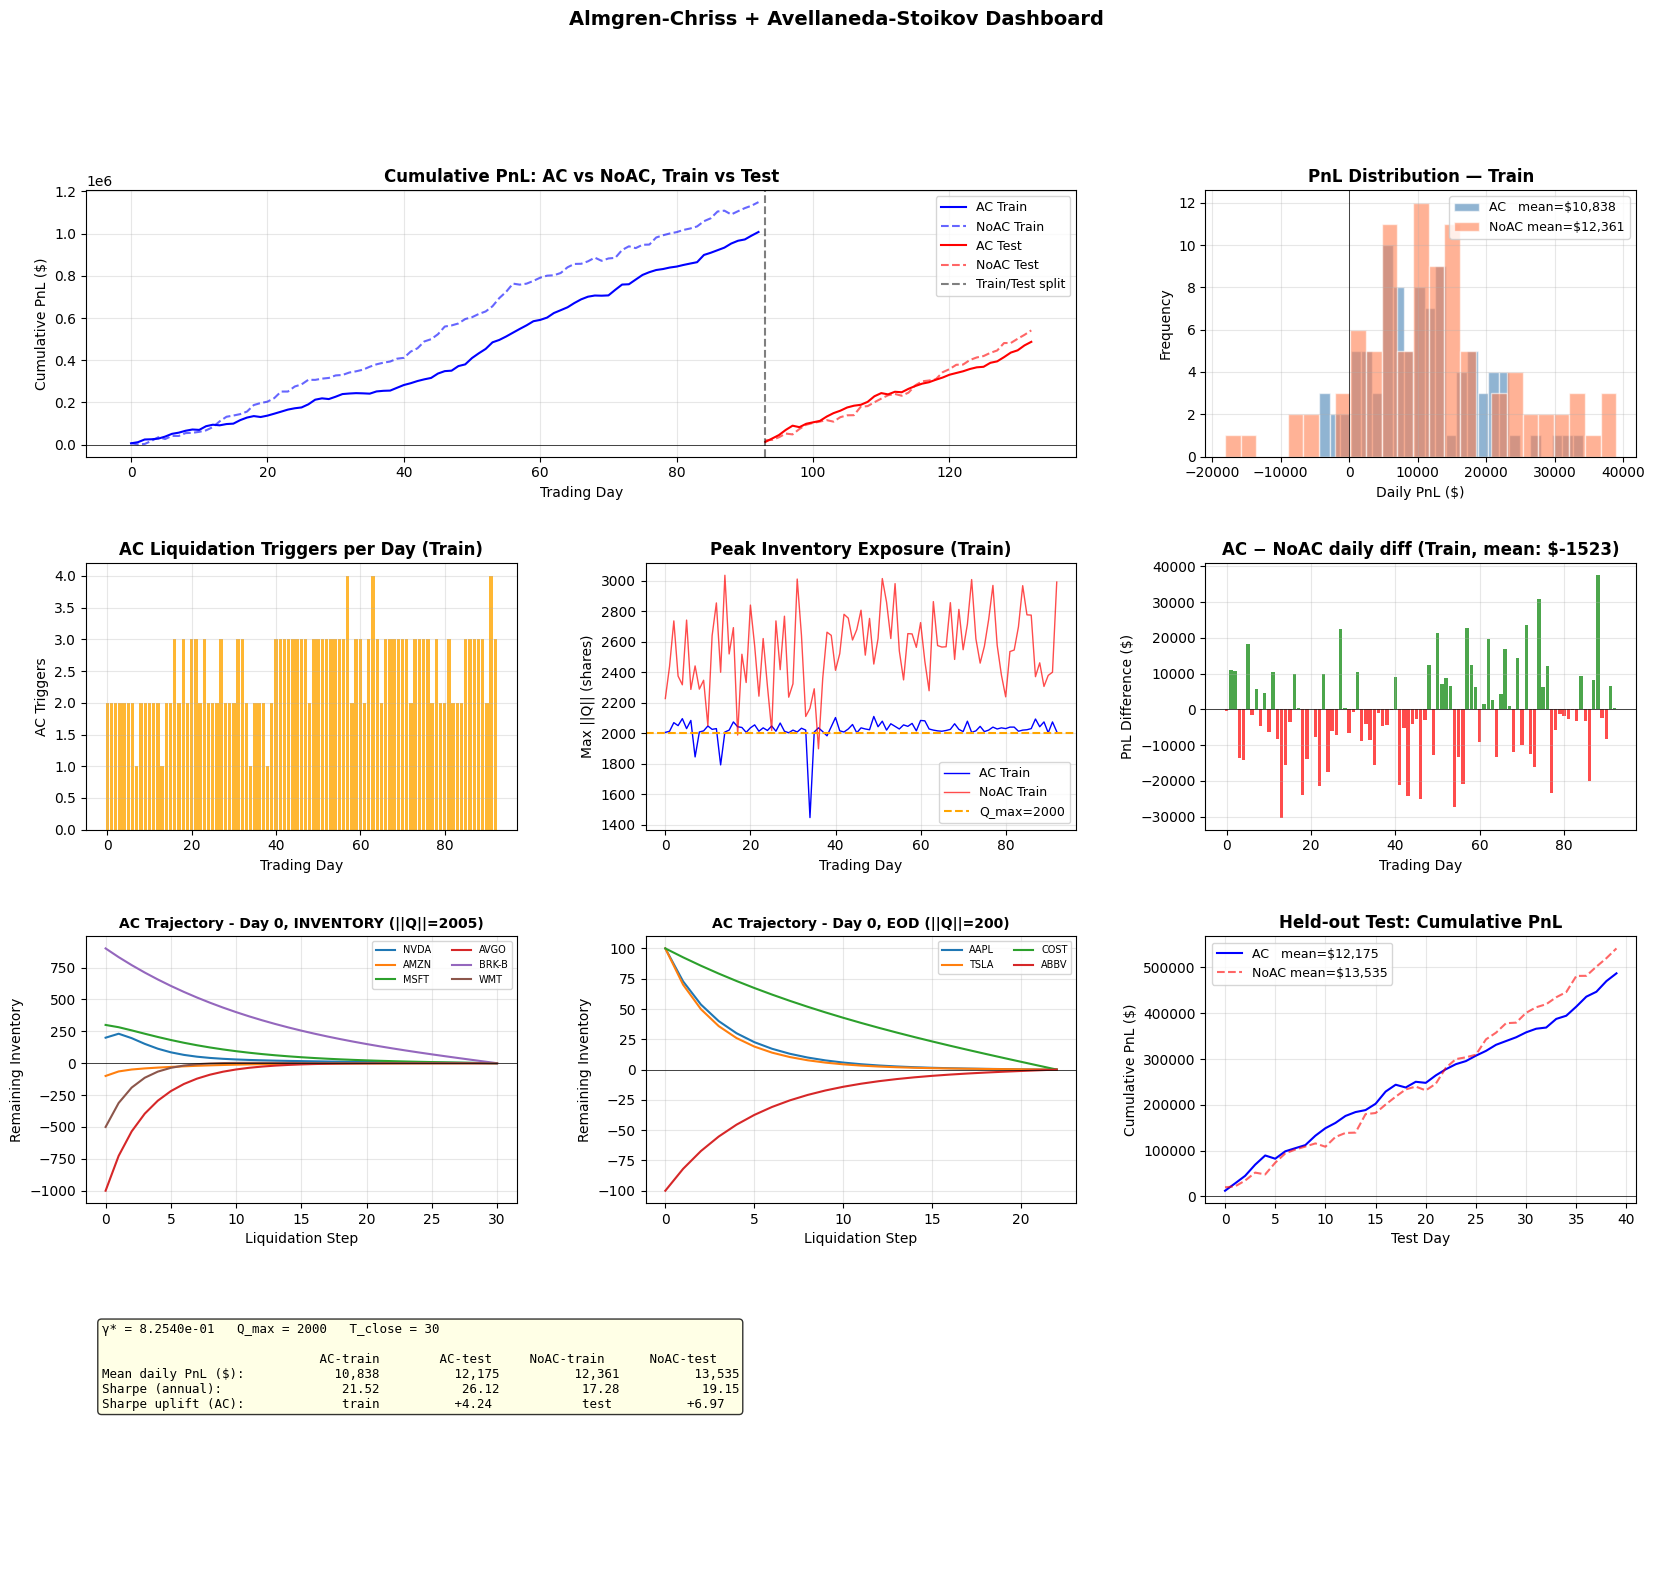

Dashboard saved → outputs/phase4_dashboard.png


In [11]:
# ── Visualisation dashboard ───────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18))
gs  = GridSpec(4, 3, figure=fig, hspace=0.4, wspace=0.3)

cum_ac_tr = np.cumsum(pnl_ac_tr); cum_no_tr = np.cumsum(pnl_no_tr)
cum_ac_te = np.cumsum(pnl_ac_te); cum_no_te = np.cumsum(pnl_no_te)
x_tr = range(len(cum_ac_tr))
x_te = range(len(cum_ac_tr), len(cum_ac_tr) + len(cum_ac_te))

ax = fig.add_subplot(gs[0, 0:2])
ax.plot(x_tr, cum_ac_tr, "b-",  linewidth=1.5, label="AC Train")
ax.plot(x_tr, cum_no_tr, "b--", linewidth=1.5, alpha=0.6, label="NoAC Train")
ax.plot(x_te, cum_ac_te, "r-",  linewidth=1.5, label="AC Test")
ax.plot(x_te, cum_no_te, "r--", linewidth=1.5, alpha=0.6, label="NoAC Test")
ax.axvline(len(cum_ac_tr), color="black", linestyle="--", alpha=0.5, label="Train/Test split")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Trading Day"); ax.set_ylabel("Cumulative PnL ($)")
ax.set_title("Cumulative PnL: AC vs NoAC, Train vs Test", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[0, 2])
ax.hist(pnl_ac_tr, bins=25, alpha=0.6, color="steelblue",
        edgecolor="white", label=f"AC   mean=${pnl_ac_tr.mean():,.0f}")
ax.hist(pnl_no_tr, bins=25, alpha=0.6, color="coral",
        edgecolor="white", label=f"NoAC mean=${pnl_no_tr.mean():,.0f}")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Daily PnL ($)"); ax.set_ylabel("Frequency")
ax.set_title("PnL Distribution — Train", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[1, 0])
ax.bar(range(len(res_ac_tr["daily_ac_triggers"])),
       res_ac_tr["daily_ac_triggers"], color="orange", alpha=0.8)
ax.set_xlabel("Trading Day"); ax.set_ylabel("AC Triggers")
ax.set_title("AC Liquidation Triggers per Day (Train)", fontweight="bold")
ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[1, 1])
ax.plot(res_ac_tr["daily_inventory_norms"], "b-", linewidth=1, label="AC Train")
ax.plot(res_no_tr["daily_inventory_norms"], "r-", linewidth=1, alpha=0.7, label="NoAC Train")
ax.axhline(Q_MAX_TRIGGER, color="orange", linestyle="--", label=f"Q_max={Q_MAX_TRIGGER}")
ax.set_xlabel("Trading Day"); ax.set_ylabel("Max ||Q|| (shares)")
ax.set_title("Peak Inventory Exposure (Train)", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[1, 2])
pnl_diff_tr = pnl_ac_tr - pnl_no_tr
colors = ["green" if d >= 0 else "red" for d in pnl_diff_tr]
ax.bar(range(len(pnl_diff_tr)), pnl_diff_tr, color=colors, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Trading Day"); ax.set_ylabel("PnL Difference ($)")
ax.set_title(f"AC − NoAC daily diff (Train, mean: ${pnl_diff_tr.mean():+.0f})",
             fontweight="bold")
ax.grid(True, alpha=0.3)

trajs = res_ac_tr["sample_ac_trajectories"]
for plot_i in range(min(2, len(trajs))):
    ax   = fig.add_subplot(gs[2, plot_i])
    traj = trajs[plot_i]
    xp   = traj["x_path"]
    for idx in np.where(np.abs(traj["Q_trigger"]) > 0.5)[0][:6]:
        ax.plot(xp[:, idx], linewidth=1.5, label=asset_names[idx])
    ax.set_xlabel("Liquidation Step"); ax.set_ylabel("Remaining Inventory")
    ax.set_title(f"AC Trajectory - Day {traj['day']}, {traj['reason']} "
                 f"(||Q||={np.linalg.norm(traj['Q_trigger']):.0f})",
                 fontweight="bold", fontsize=10)
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)
    ax.axhline(0, color="black", lw=0.5)

ax = fig.add_subplot(gs[2, 2])
ax.plot(cum_ac_te, "b-",  linewidth=1.5, label=f"AC   mean=${pnl_ac_te.mean():,.0f}")
ax.plot(cum_no_te, "r--", linewidth=1.5, alpha=0.6, label=f"NoAC mean=${pnl_no_te.mean():,.0f}")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Test Day"); ax.set_ylabel("Cumulative PnL ($)")
ax.set_title("Held-out Test: Cumulative PnL", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[3, :])
ax.axis("off")
summary_text = (
    f"γ* = {gamma_star:.4e}   Q_max = {Q_MAX_TRIGGER}   T_close = {T_CLOSE}\n\n"
    f"{'':22} {'AC-train':>14} {'AC-test':>14} {'NoAC-train':>14} {'NoAC-test':>14}\n"
    f"{'Mean daily PnL ($):':<22} {st_ac_tr['mean']:>14,.0f}  {st_ac_te['mean']:>14,.0f}  "
    f"{st_no_tr['mean']:>14,.0f}  {st_no_te['mean']:>14,.0f}\n"
    f"{'Sharpe (annual):':<22} {st_ac_tr['sharpe_a']:>14.2f}  {st_ac_te['sharpe_a']:>14.2f}  "
    f"{st_no_tr['sharpe_a']:>14.2f}  {st_no_te['sharpe_a']:>14.2f}\n"
    f"{'Sharpe uplift (AC):':<22} {'train':>14} {delta_sh_tr:>+14.2f}  "
    f"{'test':>14} {delta_sh_te:>+14.2f}"
)
ax.text(0.01, 0.95, summary_text, transform=ax.transAxes, fontsize=9,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.suptitle("Almgren-Chriss + Avellaneda-Stoikov Dashboard",
             fontsize=14, fontweight="bold")
plt.savefig("outputs/phase4_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved → outputs/phase4_dashboard.png")

In [15]:
print("Running multiseed grid...")
seeds = [1, 13, 25, 37, 89]
multiseed_results = {}
for seed in seeds:
    for cfg_name, kwargs in CONFIGS[-3:-1]:
        t0 = time.time()
        res_tr = simulate_ablation(
            gamma_star, Avec, kvec, Sigma, Gamma, H_matrix, eta_vec,
            prices_all, train_day_indices, N,
            Q_max=Q_MAX_TRIGGER, T_close=T_CLOSE, seed=seed, **kwargs)
        res_te = simulate_ablation(
            gamma_star, Avec, kvec, Sigma, Gamma, H_matrix, eta_vec,
            prices_all, test_day_indices, N,
            Q_max=Q_MAX_TRIGGER, T_close=T_CLOSE, seed=seed, **kwargs)
        multiseed_results[cfg_name] = {
            "seed": seed,
            "train": res_tr, "test": res_te,
            "st_tr": compute_stats(res_tr["daily_pnl"]),
            "st_te": compute_stats(res_te["daily_pnl"]),
        }
        print(f"  {cfg_name:<12}  {time.time()-t0:>5.0f}s  "
            f"Sh_tr={multiseed_results[cfg_name]['st_tr']['sharpe_a']:>6.2f}  "
            f"Sh_te={multiseed_results[cfg_name]['st_te']['sharpe_a']:>6.2f}  "
            f"max||Q||_tr={res_tr['daily_inventory_norms'].mean():>5.0f}")


Running multiseed grid...
  Day 20/93: PnL=$18,324, AC triggers=3, fills=789, max||Q||=2022
  Day 40/93: PnL=$6,372, AC triggers=2, fills=721, max||Q||=2002
  Day 60/93: PnL=$10,780, AC triggers=2, fills=1226, max||Q||=2022
  Day 80/93: PnL=$8,616, AC triggers=1, fills=576, max||Q||=1828
  Day 20/40: PnL=$18,000, AC triggers=2, fills=1276, max||Q||=2047
  Day 40/40: PnL=$21,333, AC triggers=3, fills=1100, max||Q||=2022
  Dual_AC          18s  Sh_tr= 23.86  Sh_te= 25.70  max||Q||_tr= 2021
  Day 20/93: PnL=$22,784, AC triggers=3, fills=795, max||Q||=2032
  Day 40/93: PnL=$7,685, AC triggers=2, fills=724, max||Q||=2020
  Day 60/93: PnL=$9,125, AC triggers=2, fills=1224, max||Q||=2007
  Day 80/93: PnL=$11,020, AC triggers=1, fills=563, max||Q||=1936
  Day 20/40: PnL=$21,843, AC triggers=2, fills=1283, max||Q||=2010
  Day 40/40: PnL=$16,160, AC triggers=3, fills=1044, max||Q||=2022
  Dual_TWAP         3s  Sh_tr= 20.92  Sh_te= 24.11  max||Q||_tr= 2022
  Day 20/93: PnL=$10,253, AC triggers=3,

In [34]:
# ── Multi-seed summary table ──────────────────────────────────────────
print(f"\n{'='*95}")
print(f"Multi-seed robustness  ({len(seeds)} seeds mean)")
print(f"{'='*95}")
print(f"{'Config':<10} {'Sh_tr':>8} {'Sh_te':>8} "
      f"{'Sh_tr_d ':>12} {'Sh_te_d':>8} "
      f"{'μPnL_te':>8} ")
print("-" * 95)
for cfg_name, _ in CONFIGS[-3:-1]:
    d = multiseed_results[cfg_name]
    sh_tr_m = np.mean(d['st_tr']['sharpe_a'])
    sh_te_m = np.mean(d['st_te']['sharpe_a'])
    sh_tr_m_d = sh_tr_m/np.sqrt(252)
    sh_te_m_d = sh_te_m/np.sqrt(252)
    pnl_te_m = np.mean(d['st_te']['mean'])
    print(f"{cfg_name:<10} {sh_tr_m:>8.2f} "
          f"{sh_te_m:>8.2f}   "
          f"{sh_tr_m_d:>8.2f}"
          f"{sh_te_m_d:>8.2f}"
          f"{pnl_te_m:>10,.0f}")


Multi-seed robustness  (5 seeds mean)
Config        Sh_tr    Sh_te     Sh_tr_d   Sh_te_d  μPnL_te 
-----------------------------------------------------------------------------------------------
Dual_AC       27.17    23.46       1.71    1.48    13,144
Dual_TWAP     22.51    19.22       1.42    1.21    13,805
